# Varian 04 — MLP 2 Hidden Layer (ReLU)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UBM-ML/REPLACE-WITH-YOUR-REPO/blob/main/notebooks/04_mlp_relu.ipynb)

**Anggota yang mengerjakan:** _Randy Frederick_

---

## 🏗️ Arsitektur
2 hidden layer: **32 neuron → 16 neuron**, lalu output 3 neuron. Arsitektur paling dalam dan paling banyak parameter di kelompok ini.

## ⚡ Fungsi Aktivasi
Kedua hidden layer menggunakan **ReLU** (rumus: f(x) = max(0, x)). Cocok untuk model yang lebih dalam karena tidak terkena vanishing gradient.

## 🎯 Goal
Menjalankan eksperimen ini, menyimpan history training, lalu commit notebook ini (dengan output yang sudah ter-render) ke repo GitHub kelompok.


## 1. Setup environment

In [1]:
# Jalankan cell ini HANYA jika kamu berada di Google Colab.
# Kalau kamu menjalankan di lokal/Jupyter, cukup pastikan kamu berada di root repo.

import os
if not os.path.exists('src'):
    # Ganti URL di bawah dengan URL repo kelompok kamu
    REPO_URL = 'https://github.com/UBM-ML/artificial-neural-network-sawit-supremacy.git'
    !git clone $REPO_URL repo
    %cd repo
print('Working dir:', os.getcwd())
print('Contents:', os.listdir('.'))


Cloning into 'repo'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 27 (delta 5), reused 0 (delta 0), pack-reused 18 (from 2)
Receiving objects: 100% (27/27), 21.02 KiB | 10.51 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/repo
Working dir: /content/repo
Contents: ['requirements.txt', 'docs', 'data', 'notebooks', 'scripts', 'README.md', 'src', '.git', '.gitignore', '.github']


## 2. Import library

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

from src.data_loader import load_iris_data
from src.utils import set_global_seed, plot_training_curves, save_history, evaluate_and_report
from src.config import EPOCHS, BATCH_SIZE, OPTIMIZER, LOSS, METRICS, VALIDATION_SPLIT, RANDOM_SEED

set_global_seed(RANDOM_SEED)
print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.20.0


## 3. Load data
Catatan: data sudah otomatis di-split, di-shuffle, dan dinormalisasi sesuai konfigurasi bersama di `src/config.py`. **Jangan diubah** supaya perbandingan adil.

In [3]:
X_train, X_test, y_train, y_test, n_features, n_classes = load_iris_data()
print(f'Jumlah fitur: {n_features}, jumlah kelas: {n_classes}')
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')


Jumlah fitur: 4, jumlah kelas: 3
X_train: (120, 4), X_test: (30, 4)


## 4. Bangun model

In [4]:
model = Sequential([
    Input(shape=(n_features,)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(n_classes, activation='softmax'),
])
model.compile(optimizer=OPTIMIZER, loss=LOSS, metrics=METRICS)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739 (2.89 KB)

 Trainable params: 739 (2.89 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Latih model
Hyperparameter (epochs, batch_size, optimizer) diambil dari `src/config.py` supaya identik dengan varian lain.

In [5]:
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    verbose=2,
)


Epoch 1/100
12/12 - 1s - 119ms/step - accuracy: 0.5417 - loss: 0.9569 - val_accuracy: 0.7083 - val_loss: 0.8753
Epoch 2/100
12/12 - 0s - 8ms/step - accuracy: 0.8229 - loss: 0.8131 - val_accuracy: 0.7083 - val_loss: 0.7809
Epoch 3/100
12/12 - 0s - 9ms/step - accuracy: 0.8542 - loss: 0.7051 - val_accuracy: 0.7500 - val_loss: 0.7057
Epoch 4/100
12/12 - 0s - 11ms/step - accuracy: 0.8333 - loss: 0.6206 - val_accuracy: 0.7083 - val_loss: 0.6427
Epoch 5/100
12/12 - 0s - 9ms/step - accuracy: 0.8438 - loss: 0.5516 - val_accuracy: 0.7083 - val_loss: 0.5892
Epoch 6/100
12/12 - 0s - 8ms/step - accuracy: 0.8542 - loss: 0.4944 - val_accuracy: 0.7917 - val_loss: 0.5450
Epoch 7/100
12/12 - 0s - 9ms/step - accuracy: 0.8542 - loss: 0.4477 - val_accuracy: 0.8333 - val_loss: 0.5080
Epoch 8/100
12/12 - 0s - 9ms/step - accuracy: 0.8542 - loss: 0.4090 - val_accuracy: 0.8750 - val_loss: 0.4751
Epoch 9/100
12/12 - 0s - 8ms/step - accuracy: 0.8542 - loss: 0.3767 - val_accuracy: 0.8750 - val_loss: 0.4458
Epoch 1

## 6. Visualisasi kurva training

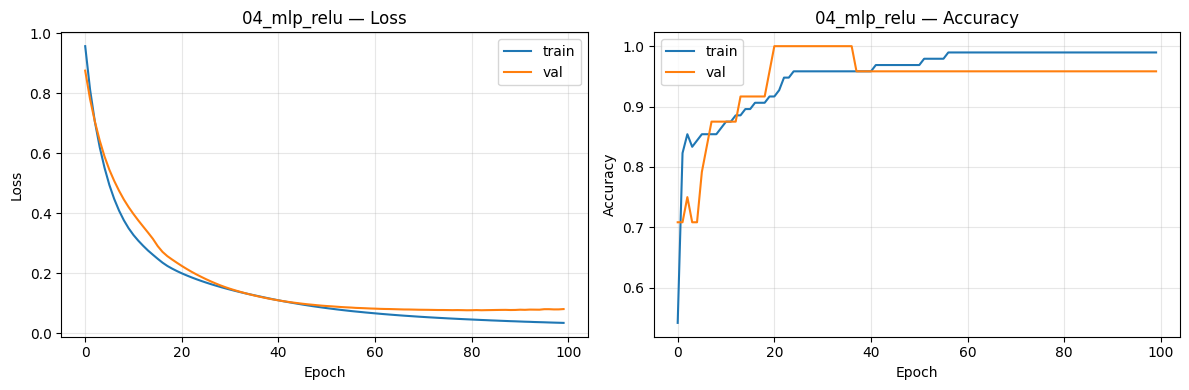

In [6]:
plot_training_curves(history, variant_name='04_mlp_relu')


## 7. Evaluasi di test set

In [7]:
summary = evaluate_and_report(model, X_test, y_test, variant_name='04_mlp_relu')
save_history(history, variant_name='04_mlp_relu')
summary



📊 04_mlp_relu
   Test loss:     0.1025
   Test accuracy: 0.9333
   Jumlah parameter: 739
✅ History tersimpan di: results/04_mlp_relu.csv


{'variant': '04_mlp_relu',
 'test_loss': 0.10249059647321701,
 'test_accuracy': 0.9333333373069763,
 'n_params': 739}

## 8. Refleksi singkat
_Diisi oleh anggota yang mengerjakan notebook ini._ Tuliskan jawaban dalam cell markdown di bawah:

1. Slide 2.8 mengklaim ReLU 'konvergen lebih cepat'. Apakah grafik loss-mu mendukung klaim ini?
2. Model ini punya parameter paling banyak — apakah accuracy-nya selalu paling tinggi? Kalau tidak, mengapa?
3. Apakah ada tanda-tanda overfitting (val_loss naik sementara train_loss turun)? Pada epoch berapa?


# Analisis Refleksi Model MLP (Varian 04 - ReLU)

---

### 1. Kecepatan Konvergensi Aktivasi ReLU
Berdasarkan pengamatan pada grafik, klaim bahwa ReLU mempercepat konvergensi terbukti sangat akurat. Hal ini ditunjukkan oleh:
*   **Penurunan Drastis**: Kurva *loss* (baik *training* maupun *validation*) mengalami penurunan yang sangat tajam bahkan sebelum pelatihan mencapai **epoch 20**.
*   **Efisiensi Gradien**: Berbeda dengan Sigmoid atau Tanh yang berisiko mengalami *vanishing gradient* di area saturasi, ReLU menjaga gradien tetap konstan di angka **1** untuk semua input positif.
*   **Optimalisasi Dini**: Sifat ini memungkinkan pembaruan bobot terjadi secara lebih masif sejak awal pelatihan sehingga model mencapai titik optimal jauh lebih awal.

---

### 2. Hubungan Jumlah Parameter dengan Akurasi
Meskipun model ini memiliki kapasitas terbesar dengan total **739 parameter**, hasil pengujian menunjukkan bahwa jumlah parameter yang banyak tidak selalu menghasilkan akurasi tertinggi secara otomatis.
*   Untuk dataset Iris yang relatif sederhana dan bersifat linear, penggunaan lapisan dengan 32 dan 16 neuron cenderung menjadi berlebihan atau **overfitting** yaitu kondisi ketika mesin terlalu setia pada dataset sehingga data dihafal sehingga sensitivitas terhadap perubahannya menjadi tinggi.
*   **Diminishing Returns** yaitu fenomena penambahan parameter tidak lagi memberikan peningkatan performa yang signifikan setelah mencapai tingkat akurasi tertentu (sekitar 93–96%), melainkan hanya menambah beban komputasi.
*   **Iverfitting**: Model yang terlalu besar pada dataset kecil justru memiliki risiko lebih tinggi untuk hanya menghafal data (*memorizing*) daripada mempelajari pola generalisasi yang sebenarnya.

---

### 3. Identifikasi Gejala Overfitting
Tanda-tanda *overfitting* mulai terdeteksi secara visual pada grafik seiring berjalannya proses pelatihan:
*   **Tren Kurva Loss**: *Train loss* terus menurun mendekati angka nol hingga epoch 100, sementara *validation loss* berhenti menurun dan mulai mendatar atau bahkan terlihat sedikit menanjak tipis setelah melewati titik tertentu.
*   **Titik Deteksi**: *Overfitting* mulai terlihat jelas sekitar **epoch 60**.
*   **Pelebaran Celah (Gap)**: Pada titik tersebut, celah antara kurva *training* dan *validation* mulai melebar. Akurasi *training* hampir menyentuh angka sempurna (**1.0** atau **100%**), sedangkan akurasi *validation* stagnan di angka **0.96**.
*   **Interpretasi**: Hal ini mengindikasikan bahwa model mulai terlalu fokus menyesuaikan diri dengan detail *noise* pada data latihan alih-alih mempertahankan kemampuan generalisasi pada data baru.